In [116]:
from src.data.load_data import load_consumption, load_generation
import pandas as pd
import seaborn as sns
%matplotlib widget

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [88]:
consumption = load_consumption()
generation = load_generation()

## EDA

### Consumption data 
- `start date` = start of the hour 
- `end date` = end of the hour
- `grid load [MWh] Calculated resolutions` = electricity taken from the grid in that hour
- `Grid load incl. hydro pumped storage [MWh] Calculated resolutions` = electricity taken from the grid + pumped-storage pumping consumption
- `Hydro pumped storage [MWh] Calculated resolutions` = electricity used for pumped-storage pumping
- `Residual load [MWh] Calculated resolutions` = grid load not covered by wind and solar (our target)

In [89]:
consumption.describe()

,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
count,17544,17544,17544,17544,17544,17544
unique,17542,17540,17281,17297,10977,17361
top,"Oct 27, 2024 2:00 AM","Mar 30, 2024 2:00 AM","60,174.25","62,996.50",1.00,"15,885.75"
freq,2,2,3,3,74,3


In [90]:
consumption.head(5)

,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Mar 1, 2024 12:00 AM","Mar 1, 2024 1:00 AM","49,611.50","51,275.50","1,664.00","28,610.50"
1,"Mar 1, 2024 1:00 AM","Mar 1, 2024 2:00 AM","48,075.75","50,337.00","2,261.25","27,862.75"
2,"Mar 1, 2024 2:00 AM","Mar 1, 2024 3:00 AM","47,663.00","51,471.00","3,808.00","27,326.25"
3,"Mar 1, 2024 3:00 AM","Mar 1, 2024 4:00 AM","48,234.00","52,043.75","3,809.75","27,592.75"
4,"Mar 1, 2024 4:00 AM","Mar 1, 2024 5:00 AM","49,060.50","51,579.25","2,518.75","28,203.00"


In [91]:
consumption.isna().sum()

Start date                                                           0
End date                                                             0
grid load [MWh] Calculated resolutions                               0
Grid load incl. hydro pumped storage [MWh] Calculated resolutions    0
Hydro pumped storage [MWh] Calculated resolutions                    0
Residual load [MWh] Calculated resolutions                           0
dtype: int64

In [92]:
consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 6 columns):
 #   Column                                                             Non-Null Count  Dtype 
---  ------                                                             --------------  ----- 
 0   Start date                                                         17544 non-null  object
 1   End date                                                           17544 non-null  object
 2   grid load [MWh] Calculated resolutions                             17544 non-null  object
 3   Grid load incl. hydro pumped storage [MWh] Calculated resolutions  17544 non-null  object
 4   Hydro pumped storage [MWh] Calculated resolutions                  17544 non-null  object
 5   Residual load [MWh] Calculated resolutions                         17544 non-null  object
dtypes: object(6)
memory usage: 822.5+ KB


Check if the dataset is structurally clean.
* We want to confirm:

    - Start date can be parsed as datetime
    - End date can be parsed as datetime
    - rows are sorted by time
    - every interval is exactly 1 hour
    - no duplicate timestamps
    - no missing hourly timestamps
    - target column is numeric
    - no nulls / weird text values in target

In [93]:
df_consumption_clean = consumption.copy()

In [94]:
# Parse the datetime columns. 
for col in ["Start date", "End date"]:
    df_consumption_clean[col] = (
        pd.to_datetime(df_consumption_clean[col]))


# Rename the target
df_consumption_clean = df_consumption_clean.rename(columns={
    "Start date": "timestamp",
    "End date": "end_timestamp",
    "Residual load [MWh] Calculated resolutions": "residual_load_mwh"
})

# Make sure target is numeric
df_consumption_clean["residual_load_mwh"] = pd.to_numeric(
    df_consumption_clean["residual_load_mwh"].str.replace(",", "", regex=False),
    errors="coerce"
)

df_consumption_clean["grid load [MWh] Calculated resolutions"] = pd.to_numeric(
    df_consumption_clean["grid load [MWh] Calculated resolutions"].str.replace(",", "", regex=False),
    errors="coerce"
)

# Convert to UTC to avoid ambihuity during DST transitions.
df_consumption_clean['timestamp'] = df_consumption_clean['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert('UTC')
df_consumption_clean["end_timestamp"] = df_consumption_clean["timestamp"] + pd.Timedelta(hours=1)

/tmp/ipykernel_93909/1428689592.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_consumption_clean[col]))
/tmp/ipykernel_93909/1428689592.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_consumption_clean[col]))


In [95]:
# Then validate structure
print(df_consumption_clean[["timestamp", "end_timestamp", "residual_load_mwh"]].dtypes)

print("Nulls:")
print(df_consumption_clean[["timestamp", "end_timestamp", "residual_load_mwh"]].isna().sum())

print("Duplicate timestamps:", df_consumption_clean["timestamp"].duplicated().sum())

print("Sorted:", df_consumption_clean["timestamp"].is_monotonic_increasing)

timestamp            datetime64[ns, UTC]
end_timestamp        datetime64[ns, UTC]
residual_load_mwh                float64
dtype: object
Nulls:
timestamp            0
end_timestamp        0
residual_load_mwh    0
dtype: int64
Duplicate timestamps: 0
Sorted: True


In [96]:
df_consumption_clean['timestamp'].min(), df_consumption_clean['timestamp'].max()

(Timestamp('2024-02-29 23:00:00+0000', tz='UTC'),
 Timestamp('2026-03-01 22:00:00+0000', tz='UTC'))

In [97]:
# Check that each row is really one hour
df_consumption_clean["duration"] = df_consumption_clean["end_timestamp"] - df_consumption_clean["timestamp"]
print("Unique durations:", df_consumption_clean["duration"].unique())

# Check for missing hours
df_consumption_clean = df_consumption_clean.sort_values("timestamp").reset_index(drop=True)

expected = pd.date_range(
    start=df_consumption_clean["timestamp"].min(),
    end=df_consumption_clean["timestamp"].max(),
    freq="h"
)

missing_hours = expected.difference(df_consumption_clean["timestamp"])
print("Missing hours:", len(missing_hours))

Unique durations: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]
Missing hours: 0


The -1 difference and 2 missing hours suggest Day-light saving hours. We will inspect those rows to confirm whether our suspicion is correct

In [98]:
bad_rows = df_consumption_clean[(df_consumption_clean["end_timestamp"] - df_consumption_clean["timestamp"]) != pd.Timedelta(hours=1)]
bad_rows[["timestamp", "end_timestamp", "residual_load_mwh"]]

# df_consumption_clean["timestamp"].duplicated().sum()

,timestamp,end_timestamp,residual_load_mwh


Our suspicion is correct, the problematic rows are due to DST

### Generation data

In [99]:
generation.describe()

,Other renewable [MWh] Calculated resolutions
count,17544.000000
mean,110.271202
std,14.007210
min,56.460000
25%,100.477500
50%,109.600000
75%,119.000000
max,145.750000


In [100]:
generation.head()

,Start date,End date,Biomass [MWh] Calculated resolutions,Hydropower [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other renewable [MWh] Calculated resolutions,Nuclear [MWh] Calculated resolutions,Lignite [MWh] Calculated resolutions,Hard coal [MWh] Calculated resolutions,Fossil gas [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Other conventional [MWh] Calculated resolutions
0,"Mar 1, 2024 12:00 AM","Mar 1, 2024 1:00 AM","4,235.50","1,821.25","5,285.75","15,712.25",3.00,120.75,-,"8,705.75","2,809.50","6,887.75",21.50,"1,864.00"
1,"Mar 1, 2024 1:00 AM","Mar 1, 2024 2:00 AM","4,201.25","1,844.50","5,180.75","15,029.00",3.25,121.00,-,"8,255.25","2,784.25","6,396.00",50.75,"1,814.50"
2,"Mar 1, 2024 2:00 AM","Mar 1, 2024 3:00 AM","4,167.75","1,792.75","5,542.25","14,791.50",3.00,121.50,-,"8,141.25","2,770.00","6,075.50",11.75,"1,806.25"
3,"Mar 1, 2024 3:00 AM","Mar 1, 2024 4:00 AM","4,163.75","1,812.75","5,914.50","14,723.50",3.25,121.00,-,"8,194.00","2,731.25","6,089.50",2.75,"1,837.00"
4,"Mar 1, 2024 4:00 AM","Mar 1, 2024 5:00 AM","4,213.50","1,854.25","5,981.00","14,873.25",3.25,121.00,-,"8,283.25","2,770.00","6,522.75",39.00,"1,828.75"


In [101]:
generation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 14 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Start date                                         17544 non-null  object 
 1   End date                                           17544 non-null  object 
 2   Biomass [MWh] Calculated resolutions               17544 non-null  object 
 3   Hydropower [MWh] Calculated resolutions            17544 non-null  object 
 4   Wind offshore [MWh] Calculated resolutions         17544 non-null  object 
 5   Wind onshore [MWh] Calculated resolutions          17544 non-null  object 
 6   Photovoltaics [MWh] Calculated resolutions         17544 non-null  object 
 7   Other renewable [MWh] Calculated resolutions       17544 non-null  float64
 8   Nuclear [MWh] Calculated resolutions               17544 non-null  object 
 9   Lignit

In [102]:
generation.isna().sum() 

Start date                                           0
End date                                             0
Biomass [MWh] Calculated resolutions                 0
Hydropower [MWh] Calculated resolutions              0
Wind offshore [MWh] Calculated resolutions           0
Wind onshore [MWh] Calculated resolutions            0
Photovoltaics [MWh] Calculated resolutions           0
Other renewable [MWh] Calculated resolutions         0
Nuclear [MWh] Calculated resolutions                 0
Lignite [MWh] Calculated resolutions                 0
Hard coal [MWh] Calculated resolutions               0
Fossil gas [MWh] Calculated resolutions              0
Hydro pumped storage [MWh] Calculated resolutions    0
Other conventional [MWh] Calculated resolutions      0
dtype: int64

In [103]:
df_generation_clean = generation.copy()

In [105]:
# Parse the datetime columns and convert to UTC to avoid ambihuity during DST transitions. We assume that the timestamps are in local time (Europe/Berlin). 
for col in ["Start date", "End date"]:
    df_generation_clean[col] = (
        pd.to_datetime(df_generation_clean[col]))

# Rename the target
df_generation_clean = df_generation_clean.rename(columns={
    "Start date": "timestamp",
    "End date": "end_timestamp",
})

# Make sure input features are numeric
date_cols = ["timestamp", "end_timestamp"]

numeric_cols = [col for col in df_generation_clean.columns if col not in date_cols]

df_generation_clean[numeric_cols] = df_generation_clean[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "", regex=False), errors="coerce")
)

# Convert to UTC to avoid ambihuity during DST transitions.
df_generation_clean['timestamp'] = df_generation_clean['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert('UTC')
df_generation_clean["end_timestamp"] = df_generation_clean["timestamp"] + pd.Timedelta(hours=1)


/tmp/ipykernel_93909/1685643896.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_generation_clean[col]))
/tmp/ipykernel_93909/1685643896.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_generation_clean[col]))


In [ ]:
df_generation_clean.dtypes

timestamp                                            datetime64[ns]
end_timestamp                                        datetime64[ns]
Biomass [MWh] Calculated resolutions                        float64
Hydropower [MWh] Calculated resolutions                     float64
Wind offshore [MWh] Calculated resolutions                  float64
Wind onshore [MWh] Calculated resolutions                   float64
Photovoltaics [MWh] Calculated resolutions                  float64
Other renewable [MWh] Calculated resolutions                float64
Nuclear [MWh] Calculated resolutions                        float64
Lignite [MWh] Calculated resolutions                        float64
Hard coal [MWh] Calculated resolutions                      float64
Fossil gas [MWh] Calculated resolutions                     float64
Hydro pumped storage [MWh] Calculated resolutions           float64
Other conventional [MWh] Calculated resolutions             float64
dtype: object

In [106]:
# Then validate structure
print(df_generation_clean[["timestamp", "end_timestamp"]].dtypes)

print("Nulls:")
print(df_generation_clean[["timestamp", "end_timestamp"]].isna().sum())

print("Duplicate timestamps:", df_generation_clean["timestamp"].duplicated().sum())

print("Sorted:", df_generation_clean["timestamp"].is_monotonic_increasing)

timestamp        datetime64[ns, UTC]
end_timestamp    datetime64[ns, UTC]
dtype: object
Nulls:
timestamp        0
end_timestamp    0
dtype: int64
Duplicate timestamps: 0
Sorted: True


In [107]:
df_generation_clean['timestamp'].min(), df_generation_clean['timestamp'].max()

(Timestamp('2024-02-29 23:00:00+0000', tz='UTC'),
 Timestamp('2026-03-01 22:00:00+0000', tz='UTC'))

In [108]:
## Check if both datasets have the same timestamps (i.e. same rows, just different columns)
df_generation_clean["timestamp"].equals(df_consumption_clean["timestamp"])


True

## Merge Dfs

In [109]:
df_merged = df_consumption_clean.merge(
    df_generation_clean,
    on=["timestamp","end_timestamp"],
    how="inner"
)
df_merged.shape


(17544, 19)

In [110]:
df_merged = df_merged.sort_values("timestamp").reset_index(drop=True)

expected = pd.date_range(df_merged["timestamp"].min(), df_merged["timestamp"].max(), freq="h")
missing = expected.difference(df_merged["timestamp"])

print("missing hours:", len(missing))


missing hours: 0


In [111]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 19 columns):
 #   Column                                                             Non-Null Count  Dtype              
---  ------                                                             --------------  -----              
 0   timestamp                                                          17544 non-null  datetime64[ns, UTC]
 1   end_timestamp                                                      17544 non-null  datetime64[ns, UTC]
 2   grid load [MWh] Calculated resolutions                             17544 non-null  float64            
 3   Grid load incl. hydro pumped storage [MWh] Calculated resolutions  17544 non-null  object             
 4   Hydro pumped storage [MWh] Calculated resolutions_x                17544 non-null  object             
 5   residual_load_mwh                                                  17544 non-null  float64            
 6   duration              

In [113]:
## Validating the residual load by comparing it to the calculated residual load from the generation data
renewable_cols = [
    # "Biomass [MWh] Calculated resolutions",
    # "Hydropower [MWh] Calculated resolutions",
    "Wind offshore [MWh] Calculated resolutions",
    "Wind onshore [MWh] Calculated resolutions",
    "Photovoltaics [MWh] Calculated resolutions",
    # "Other renewable [MWh] Calculated resolutions",
]

df_merged["calculated_renewable_generation_mwh"] = df_merged[renewable_cols].sum(axis=1)

df_merged["calculated_residual_load_mwh"] = (
    df_merged["grid load [MWh] Calculated resolutions"] - df_merged["calculated_renewable_generation_mwh"]
)

comparison_cols = [
    "timestamp",
    "residual_load_mwh",
    "calculated_residual_load_mwh",
]

df_merged[comparison_cols].head()


,timestamp,residual_load_mwh,calculated_residual_load_mwh
0,2024-02-29 23:00:00+00:00,28610.50,28610.50
1,2024-03-01 00:00:00+00:00,27862.75,27862.75
2,2024-03-01 01:00:00+00:00,27326.25,27326.25
3,2024-03-01 02:00:00+00:00,27592.75,27592.75
4,2024-03-01 03:00:00+00:00,28203.00,28203.00


## Exploring the final df

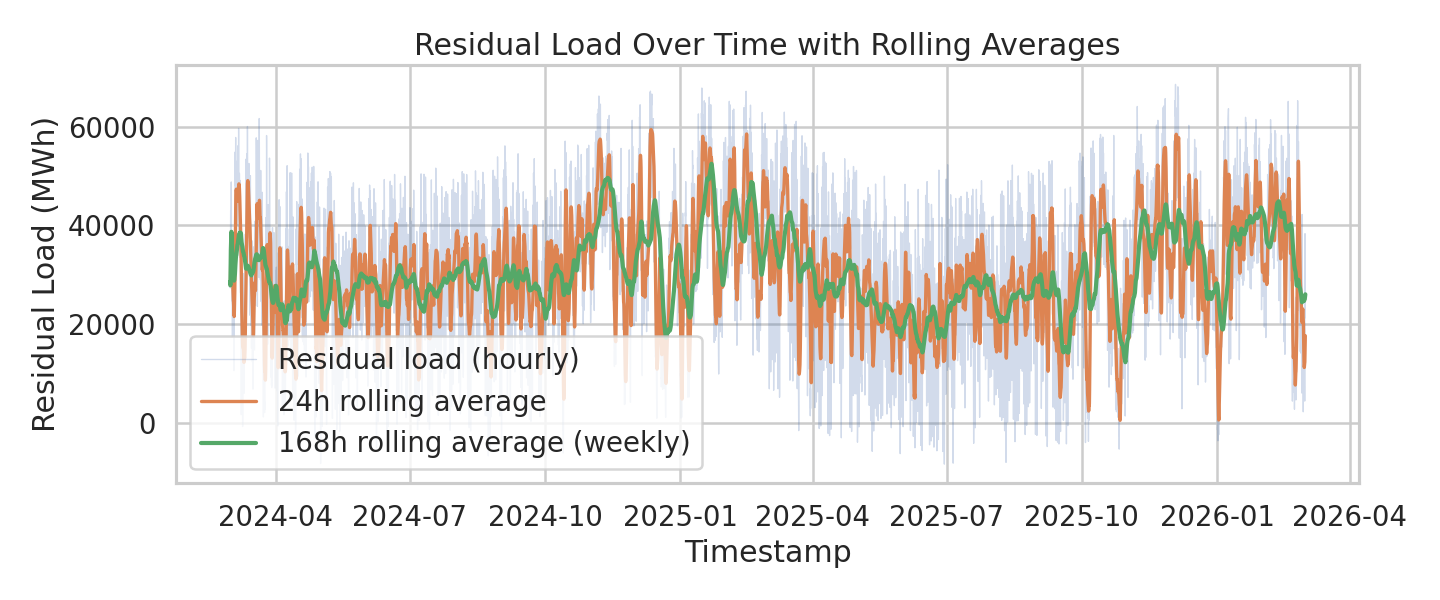

In [119]:
df_plot = df_merged.copy()

# Ensure clean, sorted time series
df_plot["timestamp"] = pd.to_datetime(df_plot["timestamp"], errors="coerce")
df_plot = df_plot.dropna(subset=["timestamp", "residual_load_mwh"]).sort_values("timestamp")

# Rolling averages (hourly data assumed)
df_plot["residual_load_ma_24h"] = (
    df_plot["residual_load_mwh"].rolling(window=24, min_periods=1).mean()
)
df_plot["residual_load_ma_168h"] = (
    df_plot["residual_load_mwh"].rolling(window=168, min_periods=1).mean()
)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 5))

# Raw hourly series
sns.lineplot(
    data=df_plot,
    x="timestamp",
    y="residual_load_mwh",
    ax=ax,
    label="Residual load (hourly)",
    alpha=0.25,
    linewidth=0.8,
)

# Smoothed trends
sns.lineplot(
    data=df_plot,
    x="timestamp",
    y="residual_load_ma_24h",
    ax=ax,
    label="24h rolling average",
    linewidth=2,
)
sns.lineplot(
    data=df_plot,
    x="timestamp",
    y="residual_load_ma_168h",
    ax=ax,
    label="168h rolling average (weekly)",
    linewidth=2.5,
)

ax.set_title("Residual Load Over Time with Rolling Averages")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Residual Load (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

### Time-Series Insights: Residual Load

From the residual load time-series (hourly) and rolling averages (24h, 168h), we observe:

1. **Pronounced seasonality**
   Residual load is generally **higher in winter months** (around Nov-Feb) and **lower in late spring/summer** (around May-Aug), indicating strong seasonal demand effects.

2. **Medium-term trend changes**
   The **168h rolling average** declines into mid-2025 (lower baseline), then rises again in late-2025 to early-2026, suggesting a regime shift rather than a purely flat long-run trend.

3. **Strong short-term variability**
   The hourly series shows substantial fluctuation around the smoothed trend, consistent with **intra-day and intra-week demand dynamics**.

4. **Winter peak concentration**
   High-load spikes (frequently above 50,000 MWh) are concentrated in colder periods, reinforcing the role of weather-driven demand pressure.

5. **Low/near-zero (and occasional negative) residual-load hours**
   These occur mostly around lower-demand/high-renewable periods and can reflect **renewable surplus conditions**. They should also be checked for data-quality consistency.

6. **Time-varying volatility**
   Variability is not constant across the sample; some periods show wider spread and more abrupt swings, which suggests potential benefit from models that can handle heteroskedastic behavior.
